In [1]:
#Import modules
import scanpy as sc
import anndata as ad
import numpy as np

%pip install torch pyro-ppl

import torch
import torch.nn as nn

import matplotlib.pyplot as plt

# Silhouette scores
from sklearn.metrics import silhouette_score
import pandas as pd


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Read data
data_source = '/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data/20260207_adata_preprocessed_full.h5ad'
adata = sc.read_h5ad(data_source)
 
#Pre-process
adata_dense = adata.X.toarray()

#Stuff below might not be needed (never used in future code)
df = adata.obs[['cell_id','cell_type_L3',]]
df.rename(columns={'cell_type_L3': 'group'}, inplace=True)
df.to_csv('df_attention.csv')

/var/folders/3p/7nndjfj95j1b_fk0h38c9_y80000gn/T/ipykernel_22111/3657082812.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'cell_type_L3': 'group'}, inplace=True)


In [3]:
# Create subset of *only* tumor cells
tumor_mask = adata.obs['cell_type_general'] == 'tumor'
adata_tumor = adata[tumor_mask].copy()

# Subset to 50k
adata_tumor_50k = sc.pp.subsample(adata_tumor, n_obs = 50000, random_state = 5, copy = True)
print(adata_tumor_50k)

AnnData object with n_obs × n_vars = 50000 × 423
    obs: 'centroid_x', 'centroid_y', 'centroid_z', 'fov', 'cluster', 'volume', 'population', 'cell_num', 'Unnamed: 0', 'sample_num', 'sample_id', 'sample_type', 'TMA', 'batch', 'log10_total_counts', 'leiden', 'density_status', 'atypical', 'deviation_score', 'log_lib_size', 'cell_type', 'TMA_ID', 'OS_days', 'survival sample date to death (days)', 'treatment_(0= no treatment before biopsy; 1=treatment before biopsy)', 'biopsy_site', 'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)', 'sample site: primary vs met', 'primary site classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic)', 'age_(yrs)', 'sex', 'PDL1 (TPS%)', 'PDL1: 0 = <1%; 1 = >=1%', 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT', 'note:', 'Registry participant? (YES/n)', 'NC registry ID', 'accession no.', 'treatment_status'

In [4]:
# Install modules
%pip install randomname
# Import modules for decipher
import pyro
import randomname
import scipy.sparse as sp


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Import decipher
import sys
sys.path.insert(0, '/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-attention')
import decipher as dc

In [32]:
# Decipher requires raw integer counts in .X; use the 'counts' layer
adata_tumor_dc = adata_tumor_50k.copy()
counts = adata_tumor_dc.layers['counts'].copy()

if sp.issparse(counts):
    counts.data = counts.data.round().astype(int)
else:
    counts = counts.round().astype(int)
adata_tumor_dc.X = counts

adata_tumor_dc_tma = adata_tumor_dc.copy()
adata_tumor_dc_eg = adata_tumor_dc.copy()
adata_tumor_dc_orig = adata_tumor_dc.copy()
adata_tumor_dc_nut_fus = adata_tumor_dc.copy()
adata_tumor_dc_sid = adata_tumor_dc.copy()


In [7]:
# Lower learning rate
from decipher.tools._decipher import DecipherConfig
config = DecipherConfig(learning_rate=1e-3)

### Train Native Decipher

Epoch 18 (batch 703/703) | | train elbo: 241.21 (last epoch: 241.28) | val ll: 248.57:   2%|▏         | 18/1000 [01:57<1:46:50,  6.53s/it]2026-05-19 19:01:07,811 | INFO : Early stopping has been triggered.
2026-05-19 19:01:07,877 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-05-19 19:01:07,878 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-05-19 19:01:07,882 | INFO : Saving decipher model with run_id 2026-05-19-19-01-07-smoked-bronze-null.


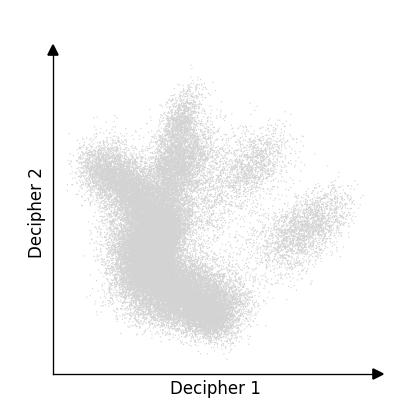

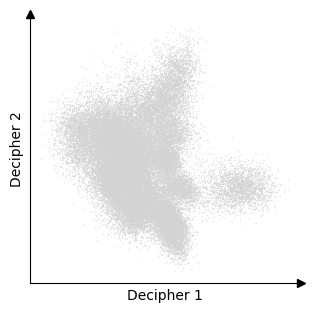

In [8]:
decipher_model_orig, _ = dc.tl.decipher_train(
    adata_tumor_dc_orig,
    decipher_config=config,
    # no batch_key
)
# Save under a distinct key so it doesn't collide
adata_tumor_dc_orig.obsm['decipher_v_original'] = adata_tumor_dc_orig.obsm['decipher_v'].copy()

### Correcting for batch_key=batch

Epoch 16 (batch 703/703) | | train elbo: 239.02 (last epoch: 238.99) | val ll: 247.15:   2%|▏         | 16/1000 [02:09<2:13:03,  8.11s/it]2026-05-19 19:03:18,617 | INFO : Early stopping has been triggered.
2026-05-19 19:03:18,703 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-05-19 19:03:18,704 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-05-19 19:03:18,705 | INFO : Saving decipher model with run_id 2026-05-19-19-03-18-simple-glum-burger.


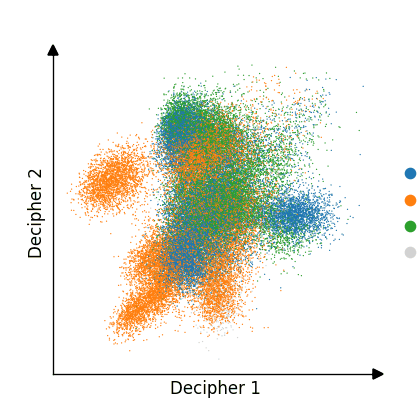

In [9]:
# Train Decipher on tumor cells
decipher_model, val_losses = dc.tl.decipher_train(
    adata_tumor_dc,
    decipher_config = config,
    plot_kwargs={"color": "ex_group"},
    batch_key = 'batch'
)

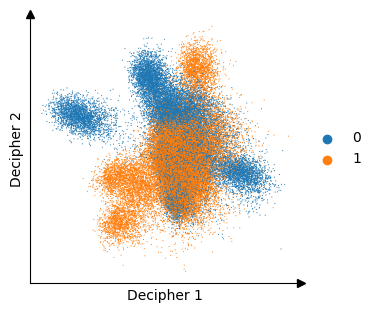

In [10]:
dc.pl.decipher(adata_tumor_dc, color='batch')

In [11]:
print(adata_tumor_dc.obs['batch'].value_counts())
print(adata_tumor_dc.obs.groupby('batch')['sample_id'].nunique())

batch
1    29075
0    20925
Name: count, dtype: int64
batch
0    23
1    30
Name: sample_id, dtype: int64


/var/folders/3p/7nndjfj95j1b_fk0h38c9_y80000gn/T/ipykernel_22111/4256945486.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata_tumor_dc.obs.groupby('batch')['sample_id'].nunique())


In [12]:
for batch in adata_tumor_dc.obs['batch'].unique():
    mask = adata_tumor_dc.obs['batch'] == batch
    print(batch, adata_tumor_dc.obsm['decipher_v'][mask, 0].mean())

0 0.05032928
1 0.2396122


In [13]:
# Does batch separate in the Decipher space?
# Plot on v space
dc.pl.decipher(adata_tumor_dc, color='sample_id')

# Does batch correlate with v1?
import scipy.stats as stats

#Print average position on v1 axis
for batch in adata_tumor_dc.obs['batch'].unique():
    mask = adata_tumor_dc.obs['batch'] == batch
    print(batch, adata_tumor_dc.obsm['decipher_v'][mask, 0].mean())

0 0.05032928
1 0.2396122


### Correcting for batch_key = ex_group

Epoch 16 (batch 703/703) | | train elbo: 238.56 (last epoch: 238.74) | val ll: 246.91:   2%|▏         | 16/1000 [02:10<2:13:36,  8.15s/it]2026-05-19 19:05:30,830 | INFO : Early stopping has been triggered.
2026-05-19 19:05:30,896 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-05-19 19:05:30,896 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-05-19 19:05:30,897 | INFO : Saving decipher model with run_id 2026-05-19-19-05-30-bipartite-auburn-path.


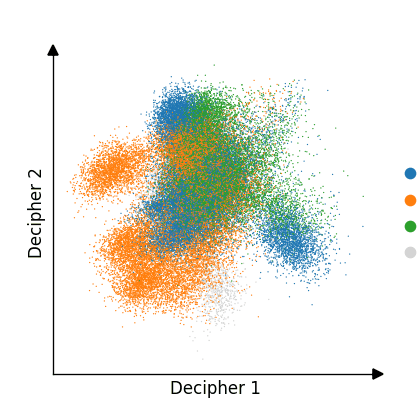

In [14]:
# Train Decipher on tumor cells, correcting for ex_group
decipher_model_eg, val_losses_eg = dc.tl.decipher_train(
    adata_tumor_dc_eg,
    decipher_config=config,
    plot_kwargs={"color": "ex_group"},
    batch_key='ex_group'
)

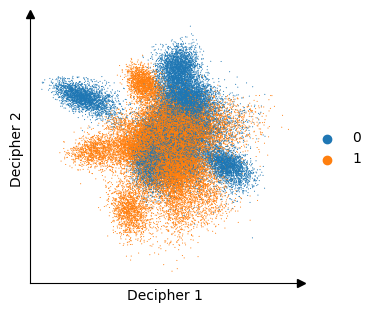

In [15]:
dc.pl.decipher(adata_tumor_dc_eg, color='batch')

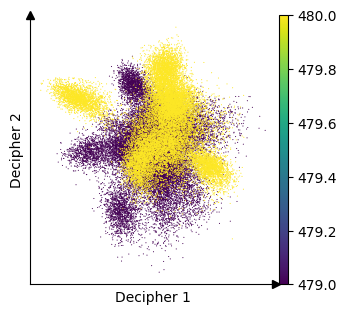

In [16]:
dc.pl.decipher(adata_tumor_dc_eg, color="TMA")

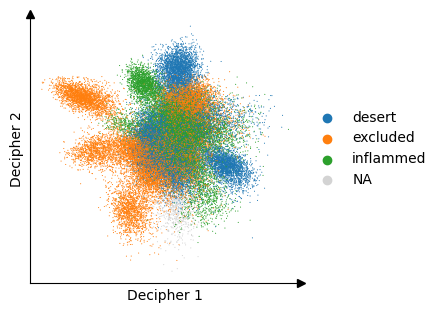

In [17]:
dc.pl.decipher(adata_tumor_dc_eg, color="ex_group")

### Correcting for batch_key=TMA
Along with subsequent silhouette scores

Epoch 16 (batch 703/703) | | train elbo: 239.02 (last epoch: 238.99) | val ll: 247.15:   2%|▏         | 16/1000 [02:12<2:15:58,  8.29s/it]2026-05-19 19:07:45,676 | INFO : Early stopping has been triggered.
2026-05-19 19:07:45,731 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-05-19 19:07:45,731 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-05-19 19:07:45,732 | INFO : Saving decipher model with run_id 2026-05-19-19-07-45-natural-camel-soy.


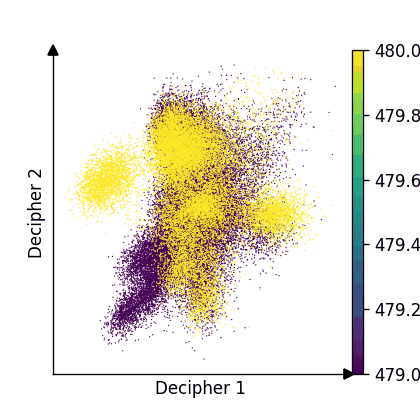

In [18]:
# Train Decipher on tumor cells, correcting for TMA
decipher_model_tma, val_losses_tma = dc.tl.decipher_train(
    adata_tumor_dc_tma,
    decipher_config=config,
    plot_kwargs={"color": "TMA"},
    batch_key='TMA'
)

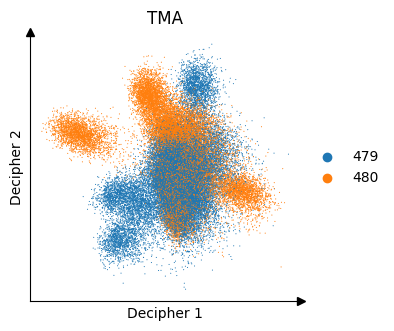

In [19]:
adata_tumor_dc_tma.obs['TMA'] = adata_tumor_dc_tma.obs['TMA'].astype(str).astype('category')
dc.pl.decipher(adata_tumor_dc_tma, color='TMA',title='TMA')

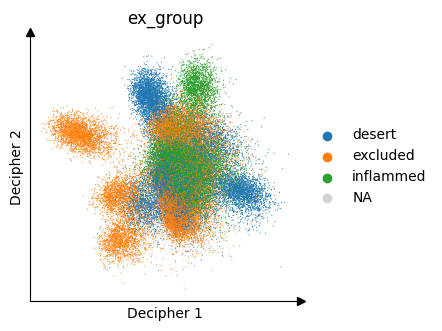

In [20]:
dc.pl.decipher(adata_tumor_dc_tma, color="ex_group", title='ex_group')

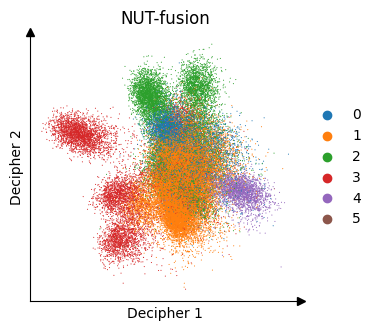

In [21]:
biopsy_col = 'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)'
nut_col    = 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT'

adata_tumor_dc_tma.obs['biopsy_site_classification'] = adata_tumor_dc_tma.obs[biopsy_col].astype(str).astype('category')
adata_tumor_dc_tma.obs['NUT_fusion'] = adata_tumor_dc_tma.obs[nut_col].astype(str).astype('category')

dc.pl.decipher(adata_tumor_dc_tma, color='NUT_fusion', title='NUT-fusion')

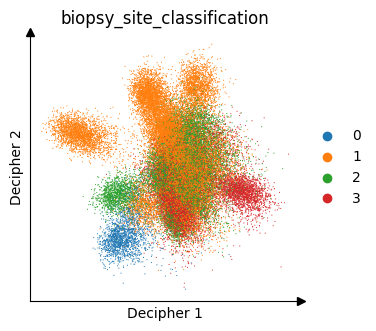

In [22]:
dc.pl.decipher(adata_tumor_dc_tma, color='biopsy_site_classification', title='biopsy_site_classification')

In [23]:
# Map display names -> actual obs column names
covariates = {
    'TMA':                       'TMA',
    'sample_id':                 'sample_id',
    'cell_type_L1':              'cell_type_L1',
    'NUT-fusion':                'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT',
    'ex_group':                  'ex_group',
    'biopsy_site':               'biopsy_site',
    'biopsy_site_classification': 'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)',
}

# These columns encode unknown as 0 — exclude those cells
unknown_value = {
    'NUT-fusion':                0,
    'biopsy_site_classification': 0,
}

def silhouette_scores(adata, embedding_key, covariates, unknown_value={}):
    X = adata.obsm[embedding_key]
    scores = {}
    for name, col in covariates.items():
        labels = adata.obs[col]
        mask = labels.notna()
        if name in unknown_value:
            mask = mask & (labels != unknown_value[name])
        labels_f = labels[mask].astype(str).values
        X_f = X[mask]
        if len(np.unique(labels_f)) < 2:
            scores[name] = np.nan
            continue
        scores[name] = silhouette_score(X_f, labels_f, random_state=42)
    return scores

scores_pca      = silhouette_scores(adata_tumor_dc_tma, 'X_pca',      covariates, unknown_value)
scores_original = silhouette_scores(adata_tumor_dc,     'decipher_v', covariates, unknown_value)
scores_tma_bc   = silhouette_scores(adata_tumor_dc_tma, 'decipher_v', covariates, unknown_value)

results = pd.DataFrame({
    'PCA':              scores_pca,
    'Original Decipher': scores_original,
    'Decipher BC':      scores_tma_bc,
}).round(4)
results['Change'] = results['Decipher BC'] - results['Original Decipher']
print(results)

                               PCA  Original Decipher  Decipher BC  Change
TMA                         0.0287             0.1039       0.1039     0.0
sample_id                   0.1502            -0.0675      -0.0675     0.0
cell_type_L1                   NaN                NaN          NaN     NaN
NUT-fusion                  0.0641            -0.0907      -0.0907     0.0
ex_group                    0.0201            -0.0184      -0.0184     0.0
biopsy_site                 0.0515            -0.2089      -0.2089     0.0
biopsy_site_classification  0.0273            -0.0277      -0.0277     0.0


In [24]:
print(np.allclose(
    adata_tumor_dc.obsm['decipher_v'],
    adata_tumor_dc_tma.obsm['decipher_v']
))
print(adata_tumor_dc.obsm.keys())
print(adata_tumor_dc_tma.obsm.keys())
print(list(adata_tumor_dc_tma.obsm.keys()))

True
KeysView(AxisArrays with keys: X_pca, X_umap, spatial, decipher_v, decipher_z)
KeysView(AxisArrays with keys: X_pca, X_umap, spatial, decipher_v, decipher_z)
['X_pca', 'X_umap', 'spatial', 'decipher_v', 'decipher_z']


In [25]:
print(adata.obs['sample_id'].unique())

['S16-2647 B2', 'BA12-166 A2', 'S14-81178 7A', 'S15-105098 B1', 'S16-25171 A1', ..., 'HA3-12 B', '10-6031', '10-I-010822 A6', 'S11-47827', 'AURMORT72213']
Length: 53
Categories (53, object): ['10-6031', '10-I-010822 A6', '10AH 4757 D', '20:LP043462 D', ..., 'S21-21003 D5', 'SF11-7078 A90', 'SP19-6233 B3', 'SUH15-11470 B1']


In [26]:
print(adata.obs['NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT'].unique())

[1 2 4 3 0 5]


### Correcting for batch_key = NUT - fusion

Epoch 15 (batch 703/703) | | train elbo: 237.05 (last epoch: 236.84) | val ll: 244.87:   2%|▏         | 15/1000 [02:01<2:13:18,  8.12s/it]2026-05-19 19:30:55,990 | INFO : Early stopping has been triggered.
2026-05-19 19:30:56,016 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-05-19 19:30:56,017 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-05-19 19:30:56,017 | INFO : Saving decipher model with run_id 2026-05-19-19-30-56-electrical-beige-range.


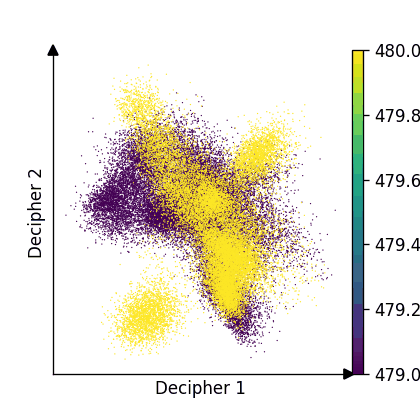

In [35]:
decipher_model_nut_fus, val_losses_nut_fus = dc.tl.decipher_train(
    adata_tumor_dc_nut_fus,
    decipher_config=config,
    plot_kwargs={"color": "TMA"},
    batch_key='NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT'
)

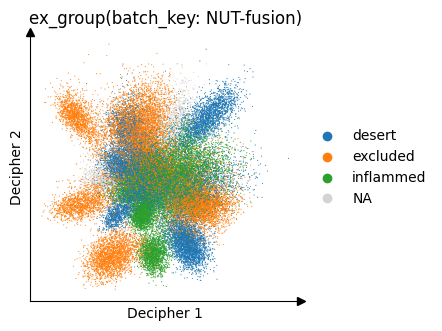

In [36]:
dc.pl.decipher(adata_tumor_dc_nut_fus, color='ex_group', title='ex_group(batch_key: NUT-fusion)')

In [37]:
dc.pl.decipher(adata_tumor_dc_tma, color='biopsy_site_classification', title='biopsy_site_classification(batch_key: NUT-fusion)')

KeyError: "Could not find 'decipher_v' or 'X_decipher_v' in .obsm"

Epoch 20 (batch 703/703) | | train elbo: 236.89 (last epoch: 236.49) | val ll: 245.52:   2%|▏         | 20/1000 [03:31<2:52:41, 10.57s/it]2026-05-19 19:26:24,044 | INFO : Early stopping has been triggered.
2026-05-19 19:26:24,116 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-05-19 19:26:24,116 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-05-19 19:26:24,117 | INFO : Saving decipher model with run_id 2026-05-19-19-26-24-blended-navy-sandwich.


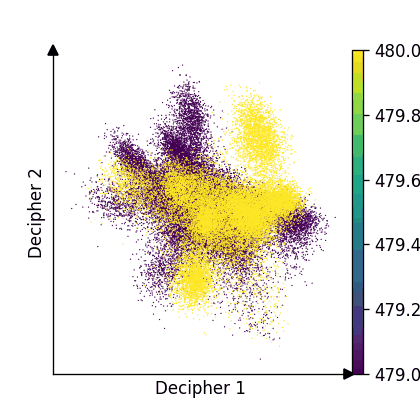

In [ ]:
decipher_model_sid, val_losses_sid = dc.tl.decipher_train(
    adata_tumor_dc_sid,
    decipher_config=config,
    plot_kwargs={"color": "TMA"},
    batch_key='sample_id'
)

In [ ]:
dc.pl.decipher(adata_tumor_dc_sid, color='ex_group', title='ex_group(batch_key: Sample ID)')

KeyError: "Could not find 'decipher_v' or 'X_decipher_v' in .obsm"

In [ ]:
dc.pl.decipher(adata_tumor_dc_sid, color='biopsy_site_classification', title='biopsy_site_classification(batch_key: Sample ID)')